In [21]:
import sqlite3

# Step 1: Connect to (or create) the database
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

# Step 2: Create a sales table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

# Step 3: Insert some sample data
sample_data = [
    ('Product A', 10, 15.0),
    ('Product B', 5, 20.0),
    ('Product C', 8, 12.5),
    ('Product A', 7, 15.0),
    ('Product B', 3, 20.0),
    ('Product C', 10, 12.5)
]

cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)

# Step 4: Commit changes and close connection
conn.commit()
conn.close()

print("✅ Database and table created, and sample data inserted.")


✅ Database and table created, and sample data inserted.


In [29]:
conn = sqlite3.connect("sales_data.db")
query = """
select * from sales
"""
df = pd.read_sql_query(query,conn)
print(df)
conn.close()

    id    product  quantity  price
0    1  Product A        10   15.0
1    2  Product B         5   20.0
2    3  Product C         8   12.5
3    4  Product A         7   15.0
4    5  Product B         3   20.0
5    6  Product C        10   12.5
6    7  Product A        10   15.0
7    8  Product B         5   20.0
8    9  Product C         8   12.5
9   10  Product A         7   15.0
10  11  Product B         3   20.0
11  12  Product C        10   12.5
12  13  Product A        10   15.0
13  14  Product B         5   20.0
14  15  Product C         8   12.5
15  16  Product A         7   15.0
16  17  Product B         3   20.0
17  18  Product C        10   12.5


Sales Summary:

     product  total_qty  revenue
0  Product A         51    765.0
1  Product B         24    480.0
2  Product C         54    675.0


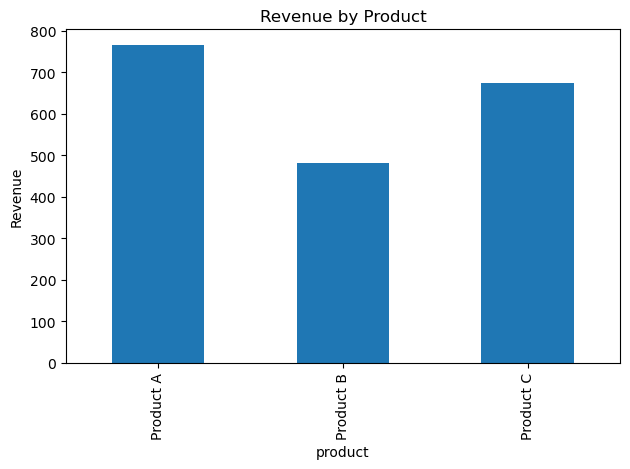

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Connect to DB
conn = sqlite3.connect("sales_data.db")

# SQL query to calculate total quantity and revenue per product
query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

# Load data into DataFrame
df = pd.read_sql_query(query, conn)

# Print summary
print("Sales Summary:\n")
print(df)

# Plot bar chart for revenue per product
df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

conn.close()

In [47]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("sales_data.db")
query = """
select product , price
from
    sales
where
    price > (select avg(price) from sales)"""
df = pd.read_sql_query(query,conn)
print(df)

     product  price
0  Product B   20.0
1  Product B   20.0
2  Product B   20.0
3  Product B   20.0
4  Product B   20.0
5  Product B   20.0
